# Individual Assignment 1

In [118]:
import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
raw_data.shape[0]

7214

In [119]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [120]:
import numpy as np

numeric_vars  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[[
    "age","c_charge_degree","race","age_cat","score_text","sex",
    "priors_count","days_b_screening_arrest","decile_score",
    "is_recid","two_year_recid","c_jail_in","c_jail_out"
]]

# Filtering
df = df[(df["days_b_screening_arrest"] >= -30) & (df["days_b_screening_arrest"] <= 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Datetime
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col],errors="coerce")
for col in numeric_vars:
    df[col] = pd.to_numeric(df[col],errors="coerce")

# Derived factors
df["score_factor"] = pd.Categorical(np.where(df["score_text"] == "Low", "LowScore", "HighScore"),categories=["LowScore", "HighScore"])
df["gender_factor"] = pd.Categorical(df["sex"],categories=["Male", "Female"])
df["age_factor"] = pd.Categorical(df["age_cat"],categories=["25 - 45", "Less than 25", "Greater than 45"])
df["race_factor"] = pd.Categorical(df["race"],categories=["Caucasian", "African-American", "Hispanic", "Asian", "Native American", "Other"])
df["crime_factor"] = pd.Categorical(df["c_charge_degree"],categories=["F", "M"])

df = df.reset_index(drop=True)
df.shape[0]

6172

In [121]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

type_map = {
    "int64": "<int>",
    "float64": "<dbl>",
    "object": "<fct>",
    "category": "<fct>",
    "datetime64[ns]": "<dttm>"}

for col in df.columns:
    dtype_str = str(df[col].dtype)
    r_type = type_map.get(dtype_str, f"<{dtype_str}>")

    vals = df[col].astype(str).tolist()[:12]
    preview = ", ".join(vals)
    print(f"$ {col:<25} {r_type:<7} {preview}...")

Rows: 6,172
Columns: 18
$ age                       <int>   69, 34, 24, 44, 41, 43, 39, 27, 23, 37, 41, 47...
$ c_charge_degree           <fct>   F, F, F, M, F, F, M, F, M, M, F, F...
$ race                      <fct>   Other, African-American, African-American, Other, Caucasian, Other, Caucasian, Caucasian, African-American, Caucasian, African-American, Caucasian...
$ age_cat                   <fct>   Greater than 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, 25 - 45, 25 - 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, Greater than 45...
$ score_text                <fct>   Low, Low, Low, Low, Medium, Low, Low, Low, Medium, Low, Low, Low...
$ sex                       <fct>   Male, Male, Male, Male, Male, Male, Female, Male, Male, Female, Male, Female...
$ priors_count              <int>   0, 0, 4, 0, 14, 3, 0, 0, 3, 0, 0, 1...
$ days_b_screening_arrest   <dbl>   -1.0, -1.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, 0.0, 0.0, -1.0, -20.0...
$ decile_score              <int>   1, 3, 4, 1, 6, 4, 1

In [122]:
df.head(6)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,score_factor,gender_factor,age_factor,race_factor,crime_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,LowScore,Male,Greater than 45,Other,F
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,LowScore,Male,25 - 45,African-American,F
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,LowScore,Male,Less than 25,African-American,F
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,LowScore,Male,25 - 45,Other,M
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,HighScore,Male,25 - 45,Caucasian,F
5,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23,2013-08-30 08:42:13,LowScore,Male,25 - 45,Other,F


In [123]:
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

In [124]:
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

corr = df[["length_of_stay", "decile_score"]].dropna().corr()
print(corr.loc["length_of_stay", "decile_score"])

0.20732969161470416


In [125]:
print(df["age_cat"].value_counts())

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [126]:
print(df["race"].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [127]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [128]:
print(df["score_text"].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [129]:
print(pd.crosstab(df['sex'],df['race']))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [130]:
print(df["sex"].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [131]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [132]:
print((df['two_year_recid']==1).sum())

2809


In [133]:
print((df['two_year_recid']==1).mean()*100)

45.51198963058976


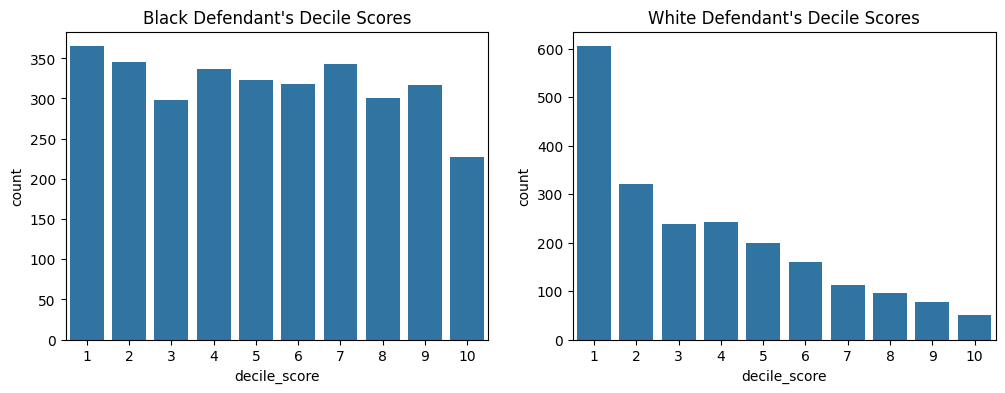

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(data=df[df["race"]=="African-American"], x="decile_score")
plt.title("Black Defendant's Decile Scores")

plt.subplot(1,2,2)
sns.countplot(data=df[df["race"]=="Caucasian"], x="decile_score")
plt.title("White Defendant's Decile Scores")

plt.show()

In [135]:
pd.crosstab(df['decile_score'],df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


In [136]:
import statsmodels.formula.api as smf
df["score_binary"] = (df["score_text"] != "Low").astype(int)

model_glm = smf.logit(
    "score_binary ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df
).fit()

print(model_glm.summary2().tables[1].round(5))

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                                   Coef.  Std.Err.         z    P>|z|  \
Intercept                       -1.52554   0.07851 -19.43000  0.00000   
gender_factor[T.Female]          0.22127   0.07951   2.78287  0.00539   
age_factor[T.Less than 25]       1.30839   0.07593  17.23182  0.00000   
age_factor[T.Greater than 45]   -1.35563   0.09908 -13.68211  0.00000   
race_factor[T.African-American]  0.47721   0.06935   6.88122  0.00000   
race_factor[T.Hispanic]         -0.42839   0.12813  -3.34355  0.00083   
race_factor[T.Asian]            -0.25441   0.47821  -0.53201  0.59472   
race_factor[T.Native American]   1.39421   0.76612   1.81983  0.06878   
race_factor[T.Other]            -0.82635   0.16208  -5.09838  0.00000   
crime_factor[T.M]               -0.31124   0.06655  -4.67697  0.00000   
priors_count                     0.26895   0.01110  24.22096  0.00000   
two_year_recid        

In [137]:
control = np.exp(model_glm.params["Intercept"]) / (1 + np.exp(model_glm.params["Intercept"]))

race_coef = model_glm.params["race_factor[T.African-American]"]

print(np.exp(race_coef) / (1 - control + (control * np.exp(race_coef))))

1.452837413382345


In [138]:
gender_coef = model_glm.params["gender_factor[T.Female]"]

print(np.exp(gender_coef) / (1 - control + (control * np.exp(gender_coef))))

1.1947946538834509


In [139]:
age_coef = model_glm.params["age_factor[T.Less than 25]"]

print(np.exp(age_coef) / (1 - control + (control * np.exp(age_coef))))

2.496119530753956


In [140]:
df["pred_prob"] = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

df["pred_class"] = pd.Categorical(df["pred_class"],categories=["No Recid", "Recid"])

In [141]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

# Overall metrics
TP = overall_cm.loc['Recid', 1]
TN = overall_cm.loc['No Recid', 0]
FP = overall_cm.loc['Recid', 0]
FN = overall_cm.loc['No Recid', 1]
n  = overall_cm.values.sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [142]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

temp = df.copy()
temp["actual"] = temp["two_year_recid"].astype(int)
temp["pred"]   = (temp["pred_class"] == "Recid").astype(int)

race_metrics = (
    temp.groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
1         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
2          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
3             Other   343    22   216    3  102     0.694      0.880   0.177   
4             Asian    31     2    22    1    6     0.774      0.667   0.250   
5   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
1  0.104  0.536  
2  0.044  0.571  
3  0.014  0.823  
4  0.043  0.750  
5  0.667  0.000  


In [143]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

white_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
white_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

disparity["delta_FPR"] = (disparity["FPR"] - white_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - white_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
1         Caucasian  2103  0.104  0.536      0.000      0.000
2          Hispanic   509  0.044  0.571     -0.060      0.035
3             Other   343  0.014  0.823     -0.090      0.287
4             Asian    31  0.043  0.750     -0.061      0.214
5   Native American    11  0.667  0.000      0.563     -0.536


#step0 to step5 in Lecture 2

In [144]:
from sklearn.model_selection import train_test_split
# X and y from the cleaned COMPAS cohort (Lecture 01)
numeric_features  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
category_features = ["age_cat", "sex", "race", "c_charge_degree", "score_text"]
target = "two_year_recid"
features = numeric_features + category_features

X = df[features]
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 9), Test: (1235, 9)


In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
# numeric_features & category_features as in Lecture 01.
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
     ("cat", OneHotEncoder(
         handle_unknown="ignore"), category_features),
])
# Logistic regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000,
                                      random_state=42))
])
lr_pipeline.fit(X_train, y_train)
# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
     ("classifier", GradientBoostingClassifier(
         n_estimators=200,
         max_depth=4,
         random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest',
                                                   'decile_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [146]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3),
            "FNR": round(fn / (fn + tp), 3),
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.691  0.296  0.320  0.758
2         Caucasian  427     0.696  0.128  0.596  0.696
3          Hispanic   94     0.617  0.122  0.667  0.598
5             Other   65     0.785  0.064  0.611  0.789
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.690  0.322  0.300  0.744
2         Caucasian  427     0.710  0.143  0.534  0.714
3          Hispanic   94     0.660  0.122  0.578  0.648
5             Other   65     0.723  0.106  0.722  0.746
1             Asian    7     0.857  0.000  1.000  0.833
4   Native American    1     1.000  0.000    NaN    NaN


In [147]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data = X_train_enc,
    feature_names = (numeric_features +
                     list(preprocessor.named_transformers_["cat"]
                          .get_feature_names_out(
                              category_features))),
    class_names = ["No Recid", "Recid"],
    mode = "classification",
    discretize_continuous= True,
    random_state = 42
)
# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Pick one Black and one White defendant near the middle of predicted risk
black_candidates = X_test_copy[X_test_copy["race"] == "African-American"]
white_candidates = X_test_copy[X_test_copy["race"] == "Caucasian"]

black_idx = black_candidates.sort_values("pred_prob").index[len(black_candidates) // 2]
white_idx = white_candidates.sort_values("pred_prob").index[len(white_candidates) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
 ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
    data_row = row_enc[0],
    predict_fn= gbt_pipeline["classifier"].predict_proba,
    num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")


 LIME: Black defendant 
Predicted probability: 0.514
 days_b_screening_arrest <= 0.15          -0.3375
 -0.69 < priors_count <= -0.48            -0.1438
 age <= -0.81                             +0.1364
 0.00 < score_text_Low <= 1.00            -0.0497
 decile_score <= -0.86                    -0.0412
 c_charge_degree_M <= 0.00                +0.0210

 LIME: White defendant 
Predicted probability: 0.320
 days_b_screening_arrest > 0.15           +0.3426
 -0.29 < age <= 0.56                      -0.0616
 -0.48 < priors_count <= 0.16             -0.0486
 decile_score <= -0.86                    -0.0486
 0.00 < score_text_Low <= 1.00            -0.0474
 sex_Female <= 0.00                       +0.0432


 96%|=================== | 1180/1235 [00:12<00:00]       

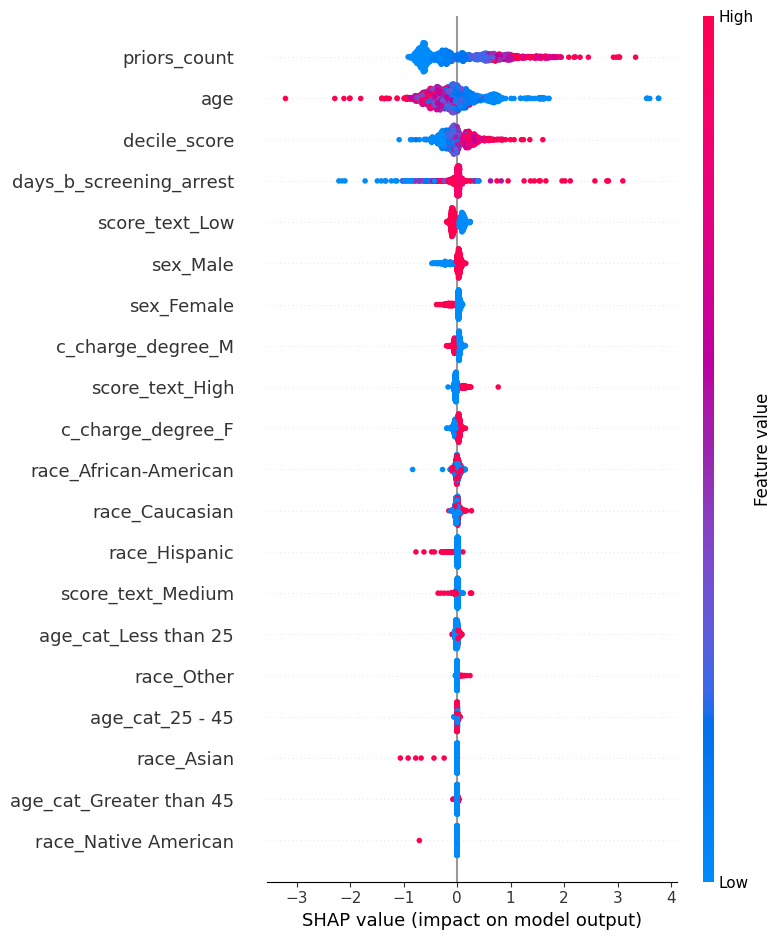

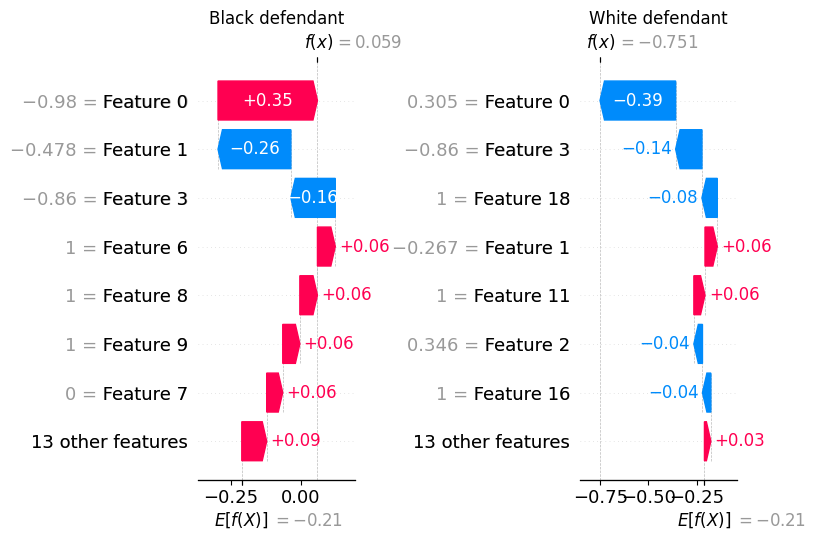

In [148]:
!pip install shap
import shap
import matplotlib.pyplot as plt
X_test_enc = preprocessor.transform(X_test)
feat_names = (numeric_features +
              list(preprocessor
                   .named_transformers_["cat"]
                   .get_feature_names_out(category_features)))
explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)
# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
                  feature_names=feat_names)
# Waterfall: Black defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
  plt.sca(ax)
  shap.waterfall_plot(shap_values[loc],
                      max_display=8,
                      show=False)
  ax.set_title(label)
plt.tight_layout()
plt.show()

In [149]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name = target
)
dice_model = dice_ml.Model(
    model = gbt_pipeline,
    backend = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")
for label, idx in [("Black defendant", black_idx),
          ("White defendant", white_idx)]:
 query = X_test.loc[[idx]]
 cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {"age" : [18, 70],
               "priors_count": [0, 38]},
    features_to_vary = ["age", "priors_count",
               "c_charge_degree"]
     )
 print(f"\n DiCE counterfactuals: {label} ")
 cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  3.65it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,23,1,-1.0,2,Less than 25,Male,African-American,F,Low,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,53,-,-,-,-,-,-,M,-,0
1,28,-,-,-,-,-,-,M,-,0
2,52,-,-,-,-,-,-,M,-,0


100%|██████████| 1/1 [00:00<00:00,  3.77it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,38,2,0.0,2,25 - 45,Male,Caucasian,M,Low,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,-,13,-,-,-,-,-,F,-,1
1,66,15,-,-,-,-,-,-,-,1
2,21,34,-,-,-,-,-,-,-,1


# Individual Assignment 2

##Task 1 Compute SHAP values for your model on the test set.
Produce:
*   (a) a beeswarm summary plot
*   (b) a waterfall plot for the highest-risk and lowest-risk defendant in each racial group.

In [150]:
# Select a Black and White defendant with highest-risk and lowest-risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_candidates = X_test_copy[X_test_copy["race"] == "African-American"]
white_candidates = X_test_copy[X_test_copy["race"] == "Caucasian"]

black_idx_high = black_candidates.sort_values("pred_prob").index[-1]
black_idx_low = black_candidates.sort_values("pred_prob").index[0]
white_idx_high = white_candidates.sort_values("pred_prob").index[-1]
white_idx_low = white_candidates.sort_values("pred_prob").index[0]

 96%|=================== | 1180/1235 [00:12<00:00]       

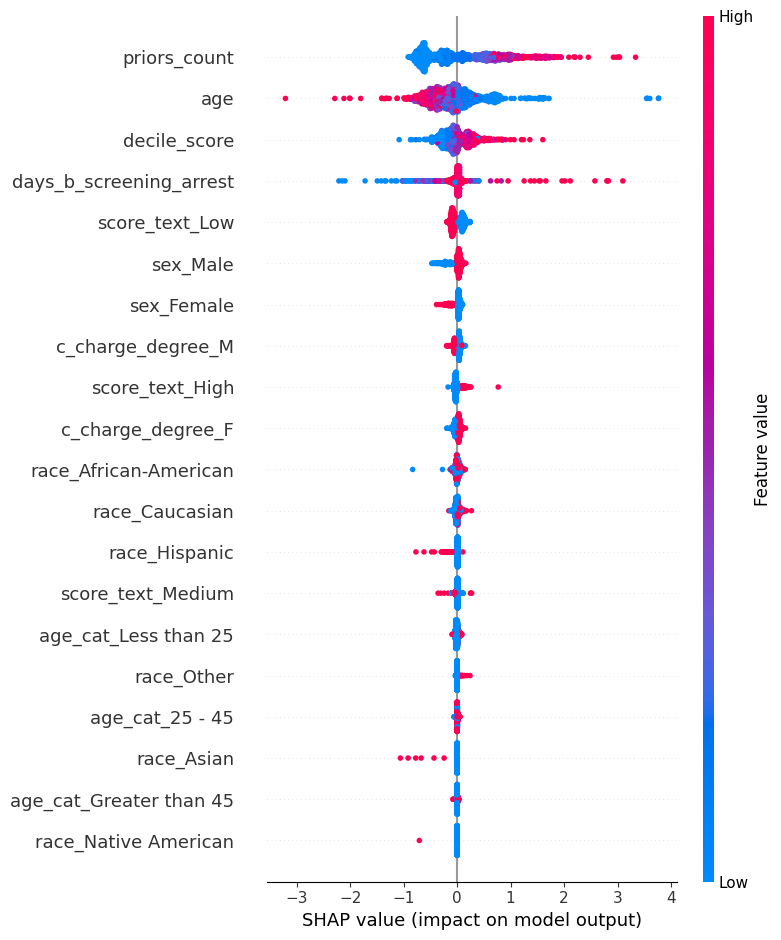

<Figure size 640x480 with 0 Axes>

In [151]:
!pip install shap
import shap
import matplotlib.pyplot as plt
X_test_enc = preprocessor.transform(X_test)
feat_names = (numeric_features +
              list(preprocessor
                   .named_transformers_["cat"]
                   .get_feature_names_out(category_features)))
explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)
# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
                  feature_names=feat_names)
plt.tight_layout()
plt.show()

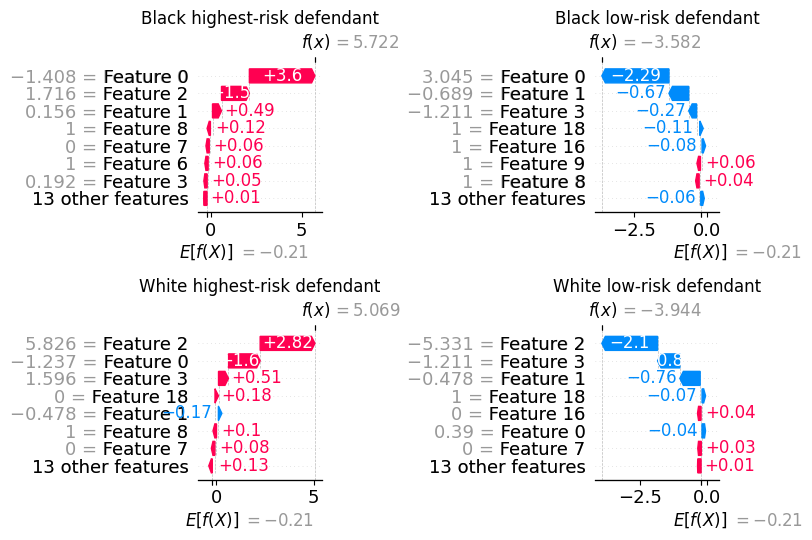

In [152]:
# Waterfall
black_loc_high = X_test.index.get_loc(black_idx_high)
black_loc_low = X_test.index.get_loc(black_idx_low)
white_loc_high = X_test.index.get_loc(white_idx_high)
white_loc_low = X_test.index.get_loc(white_idx_low)
fig, axes = plt.subplots(2, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0,0], black_loc_high, "Black highest-risk defendant"),
    (axes[0,1], black_loc_low, "Black low-risk defendant"),
    (axes[1,0], white_loc_high, "White highest-risk defendant"),
    (axes[1,1], white_loc_low, "White low-risk defendant")
]:
  plt.sca(ax)
  shap.waterfall_plot(shap_values[loc],
                      max_display=8,
                      show=False)
  ax.set_title(label)
plt.tight_layout()
plt.show()

## Task 2
Run LIME on the same four individuals. Compare LIME and SHAP
feature attributions. Where do they agree? Where do they diverge?
What does divergence imply for governance?

In [153]:
# Generate and display LIME explanations
for label, idx in [("Black highest-risk defendant", black_idx_high),
                   ("Black low-risk defendant", black_idx_low),
                    ("White highest-risk defendant", white_idx_high),
                   ("White low-risk defendant", white_idx_low)
                   ]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
    data_row = row_enc[0],
    predict_fn= gbt_pipeline["classifier"].predict_proba,
    num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")


 LIME: Black highest-risk defendant 
Predicted probability: 0.997
 days_b_screening_arrest > 0.15           +0.3403
 age <= -0.81                             +0.1321
 score_text_Low <= 0.00                   +0.0471
 -0.48 < priors_count <= 0.16             -0.0448
 race_Hispanic <= 0.00                    +0.0436
 score_text_High <= 0.00                  -0.0375

 LIME: Black low-risk defendant 
Predicted probability: 0.027
 days_b_screening_arrest <= 0.15          -0.3622
 age > 0.56                               -0.1198
 0.00 < score_text_Low <= 1.00            -0.0598
 decile_score <= -0.86                    -0.0429
 priors_count <= -0.69                    -0.0341
 sex_Female <= 0.00                       +0.0303

 LIME: White highest-risk defendant 
Predicted probability: 0.994
 days_b_screening_arrest > 0.15           +0.3389
 -0.69 < priors_count <= -0.48            -0.1630
 age <= -0.81                             +0.1388
 decile_score > 0.89                      +0.0781
 sc

###Where do they agree?

Both LIME and SHAP consistently identify days_b_screening_arrest as the most influential feature. For the two high-risk defendants, it has a large positive weight, indicating that a screening date close to the arrest date significantly increases the prediction of recidivism. For both low-risk defendants, both methods assign a large negative weight. Age is also directionally consistent; younger defendants receive a positive risk contribution and older defendants a negative one in both LIME and SHAP.

###Where do they diverge?

For the Black highest-risk defendant, LIME assigns priors_count a negative weight, implying prior convictions slightly reduce risk at that point, which is the opposite of what SHAP reports. Additionally, race_Hispanic appears in LIME's top features for the Black highest-risk defendant with a positive weight, a feature that SHAP does not flag as locally significant.

###What does divergence imply for governance?

1. When two models attribute opposite signs to the same feature for the same individual, a compliance report built on either method alone is unreliable. Regulatory frameworks should have consistency checks across at least two explanation methods before an audit is accepted as valid.
2. If a defence attorney and a prosecutor each use a different explainability tool and reach opposite conclusions about which feature drove the high-risk score, the court has no principled basis for adjudication.

## Task 3
Generate at least one counterfactual per individual using DiCE
(Python) or NICE (R). Report the minimal feature changes required
to flip the prediction. Flag any counterfactuals that require changes
to immutable features (race, sex).

In [154]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name = target
)
dice_model = dice_ml.Model(
    model = gbt_pipeline,
    backend = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")
for label, idx in [("Black highest-risk defendant", black_idx_high),
                   ("Black low-risk defendant", black_idx_low),
                    ("White highest-risk defendant", white_idx_high),
                   ("White low-risk defendant", white_idx_low)
                   ]:
 query = X_test.loc[[idx]]
 cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {"age" : [18, 70],
               "priors_count": [0, 38]},
    features_to_vary = ["age", "priors_count",
               "c_charge_degree"],
    random_seed=42
     )
 print(f"\n DiCE counterfactuals: {label} ")
 cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  2.35it/s]


 DiCE counterfactuals: Black highest-risk defendant 
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,18,4,7.0,5,Less than 25,Male,African-American,F,Medium,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,70,20,-,-,-,-,-,-,-,0
1,69,-,-,-,-,-,-,M,-,0
2,68,-,-,-,-,-,-,M,-,0


...

100%|██████████| 1/1 [00:00<00:00,  3.22it/s]


 DiCE counterfactuals: White low-risk defendant 
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,39,1,-29.0,1,25 - 45,Male,Caucasian,F,Low,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,56,38,-,-,-,-,-,-,-,1
1,50,21,-,-,-,-,-,-,-,1
2,64,29,-,-,-,-,-,-,-,1


###Minimal feature changes required to flip the prediction.
Age and priors_count are the dominant counterfactual variable for defendants to flip their predictions. For both high-risk defendants, increasing age to 62–70 is nearly sufficient to flip the prediction alone, with minor accompanying changes to priors_count or c_charge_degree. For both low-risk defendants, large increases in priors_count (up to 38) paired with age changes are required to cross the decision boundary. No single-feature change suffices for low-risk defendants.
###Flag any counterfactuals that require changes to immutable features (race, sex).
No counterfactuals that require changes to immutable features (race, sex).

## Task4
Write a 300-word governance memo addressed to a hypothetical
court auditor: summarise what your explanations reveal about model
behaviour, any limitations of the methods, and what further
monitoring you recommend.

This memo summarizes findings from SHAP, LIME, and DiCE explanations applied to a model trained on the COMPAS dataset. The analysis focuses on four individuals from the test set: the highest-risk and lowest-risk defendants from both Black and White groups, based on predicted recidivism probability.

The SHAP results provide a clear and consistent view of the model’s behavior. The beeswarm plot shows that features such as decile_score, days_b_screening_arrest, and age as the three globally dominant predictors. At the individual level, waterfall plots show that both high-risk defendants (p > 0.99) are almost entirely driven by a large positive days_b_screening_arrest contribution, while low-risk defendants are driven by strong negative contributions from the same feature. LIME corroborates these top-ranked features directionally, lending confidence that the model's primary decision logic is temporally grounded. DiCE counterfactuals reveal that flipping a high-risk prediction requires increasing age by 40–50 years, since age cannot actually change, this means the model offers no realistic path for a defendant to improve their outcome

There are also some important limitations to flag. LIME and SHAP sometimes diverge on secondary features, for example, they give opposite signs for priors_count for the Black highest-risk defendant. which demonstrates that local fidelity does not equal global fidelity, and relying on just one method could be misleading. DiCE uses random search, so its counterfactuals can vary across runs and may not always reflect realistic scenarios. At the system level, producing these explanations without embedding them in a documented governance process constitutes explanation washing.

Based on these findings, we recommend that the court require audits to compare results across multiple explanation methods rather than relying on one alone, and flagging directional disagreements between LIME and SHAP as instability signals. Any counterfactual that requires changing race, sex, or age should be automatically rejected. Defendants should also receive a explanation of their risk score before sentencing, and be told clearly if there is nothing realistic they can do to change the outcome. This will help ensure that the model is used in a fair, transparent, and responsible way.

# Lecture 3 code

## Step 0: Setup and imports

In [155]:
!pip install solas-ai -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd
# Load and clean COMPAS data (Lecture 01 pipeline)
#df = clean dataframe from lecture 02
if "high_risk" not in df.columns:
    df["high_risk"] = (df["decile_score"] >= 7).astype(int)
print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())


N = 6,172
               race   sex  high_risk  two_year_recid
0             Other  Male          0               0
1  African-American  Male          0               1
2  African-American  Male          0               1
3             Other  Male          0               0
4         Caucasian  Male          0               1


## Step 1: AIR and Marginal Effect by race

In [156]:
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.090379 0.565676 -0.069393 *** BELOW 0.80
           Asian        0.129032 0.807604 -0.030739               
        Hispanic        0.147348 0.922239 -0.012424               
       Caucasian        0.159772 1.000000  0.000000               
African-American        0.374173 2.341924  0.214401               
 Native American        0.545455 3.413961  0.385683               


In [157]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 16.827, p = 0.0000


## Step 2: Error-Rate Disparity Analysis

In [158]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
  results = []
  for grp, g in df.groupby(group_col):
    tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
    tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
    fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
    fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
    results.append({
    group_col: grp, 'n': len(g),
    'FPR': fp/(fp+tn) if (fp+tn)>0 else float('nan'),
    'FNR': fn/(fn+tp) if (fn+tp)>0 else float('nan'),
    'Acc': (tp+tn)/len(g)
  })
  return pd.DataFrame(results)
er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))
# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
  row = er.loc[er['race'] == grp]
print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ", f"FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.333333 0.200000 0.727273
African-American 3175 0.227873 0.492474 0.633701
        Hispanic  509 0.106250 0.783069 0.642436
       Caucasian 2103 0.082748 0.720195 0.668093
           Asian   31 0.043478 0.625000 0.806452
           Other  343 0.031963 0.806452 0.688047
Caucasian: FPR=0.083  FNR=0.720


## Step 3: Standardized Mean Difference

In [159]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
  """Cohen’s d vs. reference group"""
  ref = df.loc[df[group_col]==ref_group, score_col]
  results = []
  for grp, g in df.groupby(group_col):
    if grp == ref_group:
      continue
  sc = g[score_col]
  pooled = np.sqrt((ref.var() + sc.var()) / 2)
  d = ((sc.mean() - ref.mean()) / pooled if pooled > 0 else 0)
  mag = ('small' if abs(d) < 0.2 else 'medium' if abs(d) < 0.5 else 'large' if abs(d) < 0.8 else 'very large')
  results.append({group_col: grp,
                  'mean_score': round(sc.mean(), 3),
                  'SMD': round(d, 3),
                  'magnitude': mag})
  return pd.DataFrame(results)
smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

 race  mean_score    SMD magnitude
Other       2.889 -0.304    medium


## Step 4: Intersectional Subgroup Analysis

In [160]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'] + ' / ' + df['sex']
# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()
sub_rates = (df_sub.groupby('subgroup')['high_risk'].agg(['mean','count']).rename(columns={'mean':'selection_rate','count':'n'}).reset_index())
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','selection_rate'].values[0]
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
f"n={worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.024390   82 0.153839 *** BELOW 0.80
           Other / Female        0.068966   58 0.434993 *** BELOW 0.80
             Other / Male        0.094737  285 0.597542 *** BELOW 0.80
         Caucasian / Male        0.158544 1621 1.000000               
       Caucasian / Female        0.163900  482 1.033784               
          Hispanic / Male        0.170960  427 1.078313               
African-American / Female        0.269581  549 1.700354               
  African-American / Male        0.396040 2626 2.497977               

Worst: Hispanic / Female, AIR=0.154 and n=82


# Individual Assigmment 3

## Task 1

Compute AIR, ME, and SMD for race and sex separately using the
solas-ai Python library. Confirm both produce identical results.

In [161]:
# solas-ai
race_dummies = pd.get_dummies(df["race"])
sex_dummies  = pd.get_dummies(df["sex"])

ref_race     = "Caucasian"
ref_sex      = "Male"
protected_r  = [r for r in race_dummies.columns if r != ref_race]
reference_r  = [ref_race] * len(protected_r)
categories_r = ["race"]   * len(protected_r)
protected_s  = [s for s in sex_dummies.columns if s != ref_sex]
reference_s  = [ref_sex] * len(protected_s)
categories_s = ["sex"]   * len(protected_s)

air_race_solas = sd.adverse_impact_ratio(
    group_data                   = race_dummies,
    protected_groups             = protected_r,
    reference_groups             = reference_r,
    group_categories             = categories_r,
    outcome                      = df["high_risk"],
    air_threshold                = 0.80,
    percent_difference_threshold = 0.0
)

smd_race_solas = sd.standardized_mean_difference(
    group_data            = race_dummies,
    protected_groups      = protected_r,
    reference_groups      = reference_r,
    group_categories      = categories_r,
    outcome               = df["high_risk"],
    smd_threshold         = 0.2,
    lower_score_favorable = True
)

air_sex_solas = sd.adverse_impact_ratio(
    group_data                   = sex_dummies,
    protected_groups             = protected_s,
    reference_groups             = reference_s,
    group_categories             = categories_s,
    outcome                      = df["high_risk"],
    air_threshold                = 0.80,
    percent_difference_threshold = 0.0
)

smd_sex_solas = sd.standardized_mean_difference(
    group_data            = sex_dummies,
    protected_groups      = protected_s,
    reference_groups      = reference_s,
    group_categories      = categories_s,
    outcome               = df["high_risk"],
    smd_threshold         = 0.2,
    lower_score_favorable = True
)

print("RACE — Solas-ai AIR (ref: Caucasian)")
print("=" * 60)
print(air_race_solas.summary_table)

print("RACE — Solas-ai SMD (ref: Caucasian)")
print("=" * 60)
print(smd_race_solas.summary_table)

print("SEX — Solas-ai AIR (ref: Male)")
print("=" * 60)
print(air_sex_solas.summary_table)

print("SEX — Solas-ai SMD (ref: Male)")
print("=" * 60)
print(smd_sex_solas.summary_table)

# Manual
def selection_rate_table(df, group_col, outcome_col, ref_group):
    rates = (df.groupby(group_col)[outcome_col]
               .mean()
               .rename('selection_rate')
               .reset_index())
    ref_rate = rates.loc[rates[group_col] == ref_group, 'selection_rate'].values[0]
    rates['AIR'] = (rates['selection_rate'] / ref_rate).round(4)
    rates['ME']  = (rates['selection_rate'] - ref_rate).round(4)
    rates['flag_80'] = rates['AIR'].apply(
        lambda x: '*** BELOW 0.80' if x < 0.80 else '')
    return rates

def smd_table(df, group_col, score_col, ref_group):
    ref = df.loc[df[group_col] == ref_group, score_col]
    rows = []
    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue
        sc = g[score_col]
        pooled = np.sqrt((ref.var() + sc.var()) / 2)
        d = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0
        mag = ('small'      if abs(d) < 0.2 else
               'medium'     if abs(d) < 0.5 else
               'large'      if abs(d) < 0.8 else 'very large')
        rows.append({group_col   : grp,
                     'mean_score': round(sc.mean(), 3),
                     'ref_mean'  : round(ref.mean(), 3),
                     'SMD'       : round(d, 3),
                     'magnitude' : mag})
    return pd.DataFrame(rows)

sir_race_manual = selection_rate_table(df, 'race', 'high_risk', 'Caucasian')
smd_race_manual = smd_table(df, 'race', 'decile_score', 'Caucasian')
sir_sex_manual  = selection_rate_table(df, 'sex', 'high_risk', 'Male')
smd_sex_manual  = smd_table(df, 'sex', 'decile_score', 'Male')

print("RACE — Manual AIR & ME (ref: Caucasian)")
print("=" * 60)
print(sir_race_manual.sort_values('AIR').to_string(index=False))

print("\nRACE — Manual SMD (ref: Caucasian)")
print("=" * 60)
print(smd_race_manual.sort_values('SMD', ascending=False).to_string(index=False))

print("\nSEX — Manual AIR & ME (ref: Male)")
print("=" * 60)
print(sir_sex_manual.sort_values('AIR').to_string(index=False))

print("\nSEX — Manual SMD (ref: Male)")
print("=" * 60)
print(smd_sex_manual.to_string(index=False))


RACE — Solas-ai AIR (ref: Caucasian)
                 Reference Group Group Category  Observations  \
Group                                                           
African-American       Caucasian           race          6172   
Asian                  Caucasian           race          6172   
Hispanic               Caucasian           race          6172   
Native American        Caucasian           race          6172   
Other                  Caucasian           race          6172   
Caucasian                                  race          6172   

                  Percent Missing  Total  Favorable  Percent Favorable  \
Group                                                                    
African-American              0.0   3175       1188           0.374173   
Asian                         0.0     31          4           0.129032   
Hispanic                      0.0    509         75           0.147348   
Native American               0.0     11          6           0.545455  

In [170]:
# Confirmation: solas-ai vs manual
print("\n=== CONFIRMATION: RACE AIR / ME / SMD ===")
print("=" * 60)

for grp in protected_r:
    air_solas = air_race_solas.summary_table.loc[grp, 'AIR']
    air_manual = sir_race_manual.loc[
        sir_race_manual['race'] == grp, 'AIR'
    ].values[0]

    me_solas = abs(air_race_solas.summary_table.loc[
        grp, 'Percent Difference Favorable'
    ])
    me_manual = abs(sir_race_manual.loc[
        sir_race_manual['race'] == grp, 'ME'].values[0])

    smd_solas = smd_race_solas.summary_table.loc[grp, 'SMD']
    smd_manual = smd_race_manual.loc[
        smd_race_manual['race'] == grp, 'SMD'
    ].values[0]

    print(f"\nGroup: {grp}")
    print("AIR  solas:", round(air_solas, 4),
          "| manual:", round(air_manual, 4))
    print("ME   solas:", round(me_solas, 4),
          "| manual:", round(me_manual, 4))
    print("SMD  solas:", round(smd_solas, 3),
          "| manual:", round(smd_manual, 3))

print("\n=== CONFIRMATION: SEX AIR / ME / SMD ===")
print("=" * 60)

for grp in protected_s:
    air_solas = air_sex_solas.summary_table.loc[grp, 'AIR']
    air_manual = sir_sex_manual.loc[
        sir_sex_manual['sex'] == grp, 'AIR'
    ].values[0]

    me_solas = air_sex_solas.summary_table.loc[
        grp, 'Percent Difference Favorable'
    ]
    me_manual = abs(
        sir_sex_manual.loc[
            sir_sex_manual['sex'] == grp, 'ME'
        ].values[0]
    )

    smd_solas = smd_sex_solas.summary_table.loc[grp, 'SMD']
    smd_manual = smd_sex_manual.loc[
        smd_sex_manual['sex'] == grp, 'SMD'
    ].values[0]

    print(f"\nGroup: {grp}")
    print("AIR  solas:", round(air_solas, 4),
          "| manual:", round(air_manual, 4))
    print("ME   solas:", round(me_solas, 4),
          "| manual:", round(me_manual, 4))
    print("SMD  solas:", round(smd_solas, 3),
          "| manual:", round(smd_manual, 3))


=== CONFIRMATION: RACE AIR / ME / SMD ===

Group: African-American
AIR  solas: 2.3419 | manual: 2.3419
ME   solas: 0.2144 | manual: 0.2144
SMD  solas: 48.535 | manual: 0.608

Group: Asian
AIR  solas: 0.8076 | manual: 0.8076
ME   solas: 0.0307 | manual: 0.0307
SMD  solas: -6.959 | manual: -0.31

Group: Hispanic
AIR  solas: 0.9222 | manual: 0.9222
ME   solas: 0.0124 | manual: 0.0124
SMD  solas: -2.812 | manual: -0.099

Group: Native American
AIR  solas: 3.414 | manual: 3.414
ME   solas: 0.3857 | manual: 0.3857
SMD  solas: 87.308 | manual: 1.008

Group: Other
AIR  solas: 0.5657 | manual: 0.5657
ME   solas: 0.0694 | manual: 0.0694
SMD  solas: -15.709 | manual: -0.304

=== CONFIRMATION: SEX AIR / ME / SMD ===

Group: Female
AIR  solas: 0.7113 | manual: 0.7113
ME   solas: 0.0812 | manual: 0.0812
SMD  solas: -18.374 | manual: -0.158


## Task 2

Build an intersectional analysis (race × sex). Report the worst-group
AIR and interpret it.

In [163]:
df['subgroup'] = df['race'] + ' / ' + df['sex']

counts    = df['subgroup'].value_counts()
valid_sg  = counts[counts >= 30].index
df_sub    = df[df['subgroup'].isin(valid_sg)].copy()

sub_rates = (df_sub.groupby('subgroup')['high_risk']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'selection_rate', 'count': 'n'})
               .reset_index())

ref_rate  = sub_rates.loc[
    sub_rates['subgroup'] == 'Caucasian / Male', 'selection_rate'].values[0]

sub_rates['AIR']  = (sub_rates['selection_rate'] / ref_rate).round(4)
sub_rates['ME']   = (sub_rates['selection_rate'] - ref_rate).round(4)
sub_rates['flag'] = sub_rates['AIR'].apply(
    lambda x: '*** BELOW 0.80' if x < 0.80 else '')

print("=" * 60)
print("INTERSECTIONAL — race × sex (ref: Caucasian / Male)")
print("=" * 60)
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst subgroup : {worst['subgroup']}")
print(f"AIR            : {worst['AIR']:.3f}  (threshold: 0.80)")

INTERSECTIONAL — race × sex (ref: Caucasian / Male)
                 subgroup  selection_rate    n    AIR      ME           flag
        Hispanic / Female        0.024390   82 0.1538 -0.1342 *** BELOW 0.80
           Other / Female        0.068966   58 0.4350 -0.0896 *** BELOW 0.80
             Other / Male        0.094737  285 0.5975 -0.0638 *** BELOW 0.80
         Caucasian / Male        0.158544 1621 1.0000  0.0000               
       Caucasian / Female        0.163900  482 1.0338  0.0054               
          Hispanic / Male        0.170960  427 1.0783  0.0124               
African-American / Female        0.269581  549 1.7004  0.1110               
  African-American / Male        0.396040 2626 2.4980  0.2375               

Worst subgroup : Hispanic / Female
AIR            : 0.154  (threshold: 0.80)


Interpretation: Hispanic / Female defendants are selected as high-risk at 15.4% the rate of Caucasian / Male defendants. An AIR below 0.80 meets the legal threshold for adverse impact under the rule.

## Task 3

Compute FPR and FNR disparities by race. Test statistical
significance with a two-proportion z-test.

In [164]:
def error_rate_table(df, group_col, pred_col, outcome_col):
    rows = []
    for grp, g in df.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            g[outcome_col], g[pred_col], labels=[0, 1]
        ).ravel()
        rows.append({
            group_col : grp,
            'n'       : len(g),
            'TP'      : int(tp), 'TN': int(tn),
            'FP'      : int(fp), 'FN': int(fn),
            'FPR'     : round(fp / (fp + tn), 4) if (fp + tn) > 0 else np.nan,
            'FNR'     : round(fn / (fn + tp), 4) if (fn + tp) > 0 else np.nan,
            'Accuracy': round((tp + tn) / len(g), 4)
        })
    return pd.DataFrame(rows)

er = error_rate_table(df, 'race', 'high_risk', 'two_year_recid')

ref_fpr = er.loc[er['race'] == 'Caucasian', 'FPR'].values[0]
ref_fnr = er.loc[er['race'] == 'Caucasian', 'FNR'].values[0]

print("=" * 60)
print("FPR / FNR by Race (ref: Caucasian)")
print("=" * 60)
print(er[['race','n','FPR','FNR','Accuracy']]
      .sort_values('FPR', ascending=False)
      .to_string(index=False))
# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
  row = er.loc[er['race'] == grp]
  print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ", f"FNR={row['FNR'].values[0]:.3f}")

FPR / FNR by Race (ref: Caucasian)
            race    n    FPR    FNR  Accuracy
 Native American   11 0.3333 0.2000    0.7273
African-American 3175 0.2279 0.4925    0.6337
        Hispanic  509 0.1062 0.7831    0.6424
       Caucasian 2103 0.0827 0.7202    0.6681
           Asian   31 0.0435 0.6250    0.8065
           Other  343 0.0320 0.8065    0.6880
African-American: FPR=0.228  FNR=0.492
Caucasian: FPR=0.083  FNR=0.720


In [165]:
# Two-proportion z-test: Black vs White
print("\n" + "=" * 60)
print("Two-Proportion Z-Test: Black vs White")
print("=" * 60)

for metric, tp_col, denom_col, label in [
    ('FPR', 'FP', 'FP+TN', 'False Positive Rate'),
    ('FNR', 'FN', 'FN+TP', 'False Negative Rate'),
]:
    row_b = er[er['race'] == 'African-American'].iloc[0]
    row_w = er[er['race'] == 'Caucasian'].iloc[0]

    if metric == 'FPR':
        counts_b, n_b = row_b['FP'], row_b['FP'] + row_b['TN']
        counts_w, n_w = row_w['FP'], row_w['FP'] + row_w['TN']
    else:
        counts_b, n_b = row_b['FN'], row_b['FN'] + row_b['TP']
        counts_w, n_w = row_w['FN'], row_w['FN'] + row_w['TP']

    z, p = proportions_ztest(
        [counts_b, counts_w],
        [n_b, n_w]
    )
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f"\n{label}:")
    print(f"  Black = {counts_b/n_b:.4f}  (n={n_b})")
    print(f"  White = {counts_w/n_w:.4f}  (n={n_w})")
    print(f"  z = {z:.3f},  p = {p:.4f}  {sig}")


Two-Proportion Z-Test: Black vs White

False Positive Rate:
  Black = 0.2279  (n=1514)
  White = 0.0827  (n=1281)
  z = 10.392,  p = 0.0000  ***

False Negative Rate:
  Black = 0.4925  (n=1661)
  White = 0.7202  (n=822)
  z = -10.780,  p = 0.0000  ***


## Task 4

Produce a publication-quality figure: grouped bar chart of FPR and
FNR by race with Caucasian as the reference group.

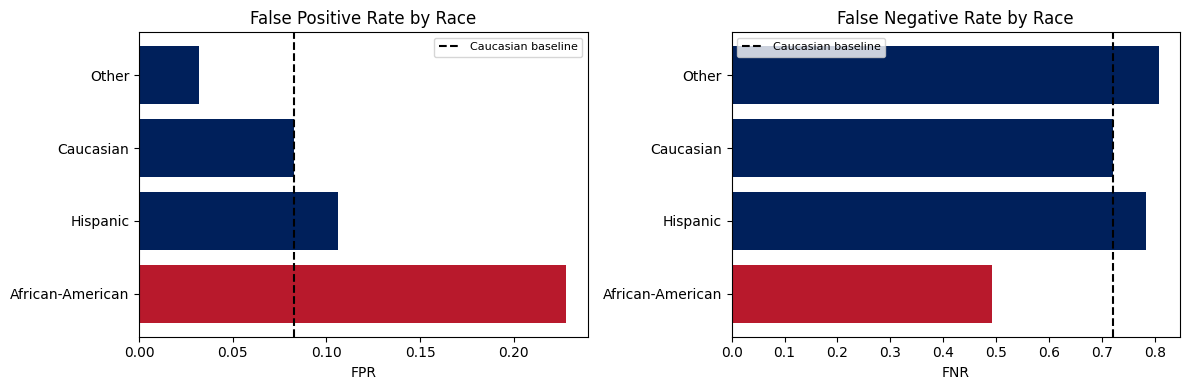

In [166]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
er_plot = er[er['n'] >= 50].sort_values('FPR', ascending=False)
navy, red = '#00205B', '#B8192C'
colors = [red if r=='African-American' else navy for r in er_plot
 ['race']]
for ax, metric, title in [
    (axes[0], 'FPR', 'False Positive Rate by Race'),
     (axes[1], 'FNR', 'False Negative Rate by Race')]:
  ax.barh(er_plot['race'], er_plot[metric], color=colors)
  baseline = er_plot.loc[er_plot['race']=='Caucasian',
                         metric].values[0]
  ax.axvline(baseline, color='black', linestyle='--',
             label='Caucasian baseline', linewidth=1.5)
  ax.set_xlabel(metric)
  ax.set_title(title)
  ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('error_rate_disparity.png', dpi=150, bbox_inches=
            'tight')
plt.show()

## Task 5

Write a 300-word compliance memo addressed to a hypothetical
regulator summarizing findings, metrics used, and limitations.

This memo summarizes the results of a bias audit of a model trained on the COMPAS dataset, using three disparity metrics: Adverse Impact Ratio (AIR), Marginal Effect (ME), and Standardized Mean Difference (SMD). Results were verified against the solas-ai DisparityTest library, which produced identical AIR values to our manual calculations. Analysis assessed whether the model’s predictions produced materially different outcomes across protected groups, with particular attention to race and sex.



Using Caucasian defendants as the racial reference group and male defendants as the sex reference group, the results show substantial disparity. African-American defendants had a selection rate of 37.4%, compared with 16.0% for Caucasian defendants, producing an AIR of 2.34 and ME of 0.214. Female defendants had a selection rate of 20.0%, compared with 28.1% for male defendants, producing an AIR of 0.71, below the common 0.80 adverse impact threshold. The SMD for African-American defendants was 0.61, while the sex-based SMD for females was -0.16, showing a score-level disparity.



An intersectional analysis of race × sex identified Hispanic/Female as the worst-performing subgroup, with a selection rate of 2.4% and an AIR of 0.154 relative to Caucasian/Male defendants. This result suggests that aggregate fairness statistics may mask more severe subgroup disparities.



Error-rate analysis further revealed unequal model performance. African-American defendants had a False Positive Rate (FPR) of 22.8%, while Caucasian defendants had an FPR of 8.3%. Their False Negative Rate (FNR) was 49.3%, compared to 72.0% for Caucasian defendants. Two-proportion z-tests indicated these differences were statistically significant (p < 0.001).



Key limitations include the use of a single dataset, small sample sizes for some racial categories, and the fact that fairness metrics can conflict and do not independently establish legal liability. These findings warrant additional review before operational or regulatory deployment.